In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Генерация примера: продажи магазина за 100 дней
dates = pd.date_range('2024-01-01', periods=100, freq='D')
sales = [100 + i*0.5 + 10*(i%7==0) + 5*(i%30==0) for i in range(100)]  # тренд + недельная сезонность + месячная

In [3]:
df = pd.DataFrame({'date': dates, 'sales': sales})
df.set_index('date', inplace=True)

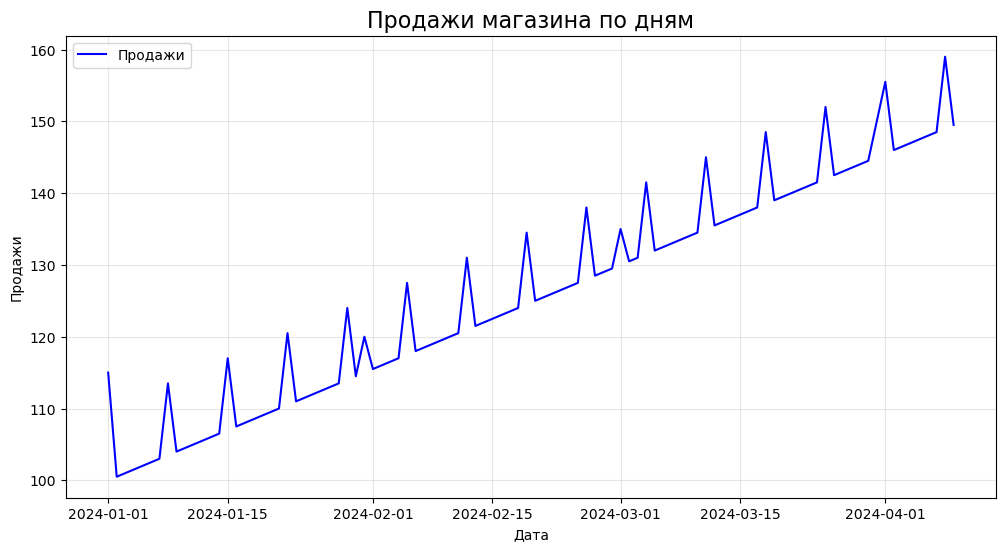

In [4]:
# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['sales'], label='Продажи', color='blue')
plt.title('Продажи магазина по дням', fontsize=16)
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [5]:
# ✅ Результат: график, показывающий рост (тренд), пики каждую неделю (сезонность) и случайные колебания (шум).

🔺 Тренд (Trend)

Общее направление движения данных в долгосрочной перспективе 

🔹 Примеры:

-	Постепенный рост продаж из-за маркетинга
-	Снижение активности пользователей
-	Увеличение числа заказов из-за расширения рынка

🧠 Как запомнить:

Это основной путь, куда движется процесс. Как река — в каком направлении она течёт? 

In [7]:
# 🐍 Python: Выделение тренда (линейная регрессия)
from sklearn.linear_model import LinearRegression
import numpy as np

In [8]:
# Подготовка данных
X = np.arange(len(df)).reshape(-1, 1)  # индексы дней
y = df['sales'].values                # значения продаж

In [9]:
# Обучение модели
model = LinearRegression()
model.fit(X, y)
trend = model.predict(X)

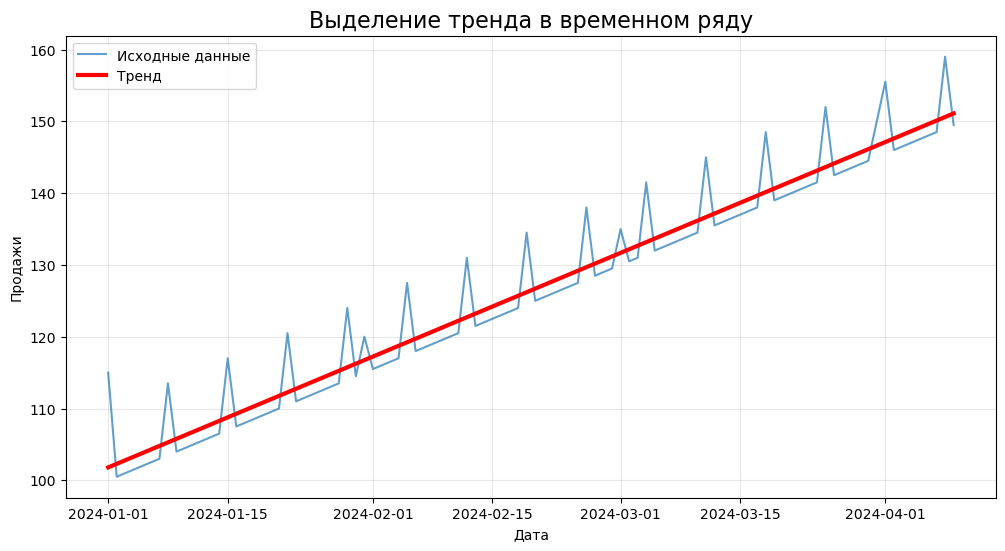

In [10]:
# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['sales'], label='Исходные данные', alpha=0.7)
plt.plot(df.index, trend, label='Тренд', linewidth=3, color='red')
plt.title('Выделение тренда в временном ряду', fontsize=16)
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#🟣 Тренд помогает ответить: «Растёт ли бизнес?», «Есть ли спад?» 

In [11]:
#🌞 Сезонность (Seasonality)
#Повторяющиеся паттерны через равные промежутки времени 
#🔹 Примеры:
#•	Продажи мороженого летом
#•	Пик трафика на сайте в обед
#🧠 Как запомнить:
#Это как предсказуемые качели — вы знаете, когда будет подъём и спад. 

In [12]:
#🐍 Python: Декомпозиция ряда (тренд + сезонность + шум)
from statsmodels.tsa.seasonal import seasonal_decompose

In [13]:
# Декомпозиция (разложение)
result = seasonal_decompose(df['sales'], model='additive', period=7)  # период = 7 дней

C:\Users\MININAA\AppData\Local\Temp\ipykernel_3012\3448205502.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 1200x1000 with 0 Axes>

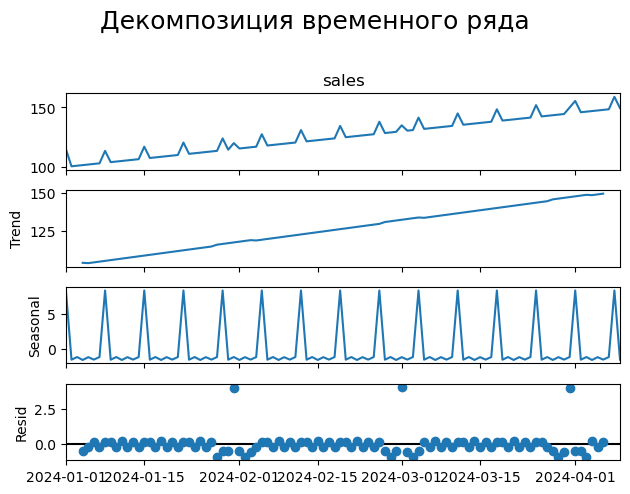

In [14]:
# Визуализация всех компонентов
plt.figure(figsize=(12, 10))
result.plot()
plt.suptitle('Декомпозиция временного ряда', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
#📌 Компоненты:
#•	Observed — исходные данные
#•	Trend — основной тренд
#•	Seasonal — повторяющийся паттерн
#•	Residual — шум (остатки)

In [ ]:
#🔊 Шум / Остатки (Noise / Residuals)
#Случайные колебания, не объясняемые трендом или сезонностью 
#🔹 Примеры:
#•	Всплеск продаж из-за упоминания в СМИ
#•	Сбой в логистике
#•	Неожиданная акция конкурента
#🧠 Как запомнить:
#Это необъяснимые случайности — то, что нельзя предсказать заранее. 
#🟣 Если шума слишком много — возможно, вы упустили важную сезонность или внешний фактор. 
________________________________________


In [15]:
#🐍 Прогнозирование временного ряда (ARIMA)

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

In [16]:
# Разделение на train/test
train = df['sales'][:80]   # первые 80 дней
test = df['sales'][80:]    # последние 20 дней

In [17]:
# Обучение модели ARIMA(p,d,q) = (1,1,1)
model = ARIMA(train, order=(1,1,1))
fitted_model = model.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [18]:
# Прогноз на 20 шагов
forecast = fitted_model.forecast(steps=20)

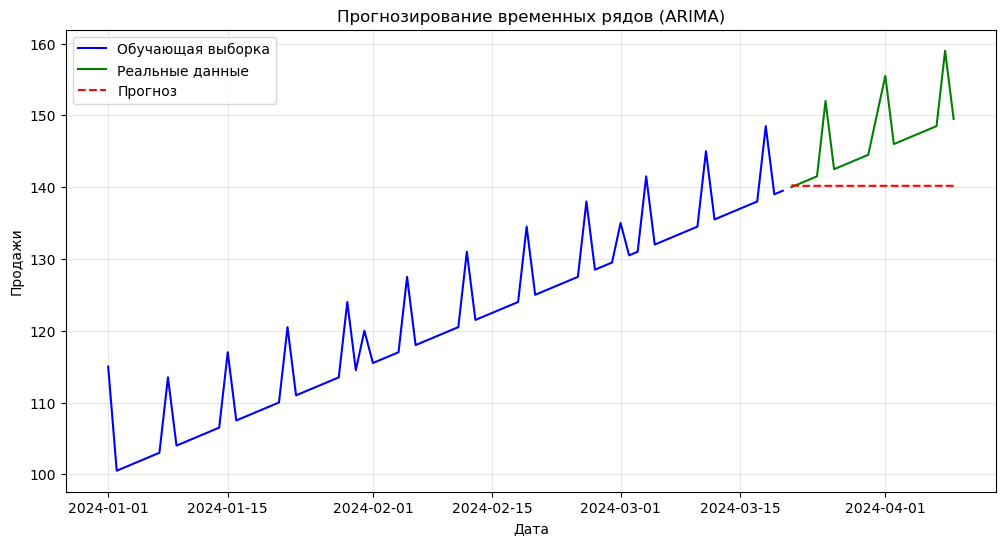

In [19]:
# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Обучающая выборка', color='blue')
plt.plot(test.index, test, label='Реальные данные', color='green')
plt.plot(test.index, forecast, label='Прогноз', color='red', linestyle='--')
plt.title('Прогнозирование временных рядов (ARIMA)')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# Оценка ошибки
mae = mean_absolute_error(test, forecast)
print(f"Средняя абсолютная ошибка (MAE): {mae:.2f}")

Средняя абсолютная ошибка (MAE): 6.34


In [ ]:
#✅ Используйте для прогнозирования: 
#•	Продаж
#•	Числа клиентов
#•	Загрузки серверов
#•	Бюджета
